In [1]:
import sys
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from starcat import BuildConsensusReference, starCAT

/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/minicon

In [2]:
adata = sc.read_h5ad("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/5.startCAT-SLE/GSE135779_PBMC_SLE_Adult_celltype_harmony_umap.h5ad")
adata


AnnData object with n_obs × n_vars = 68762 × 21024
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'join_key', 'index', 'IDs', 'Names', 'SLEDAI', 'subclusters', 'clean_seq', 'sample', 'group', 'age_group', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype', 'barcode'
    obsm: 'X_harmony', 'X_pca', 'X_umap'

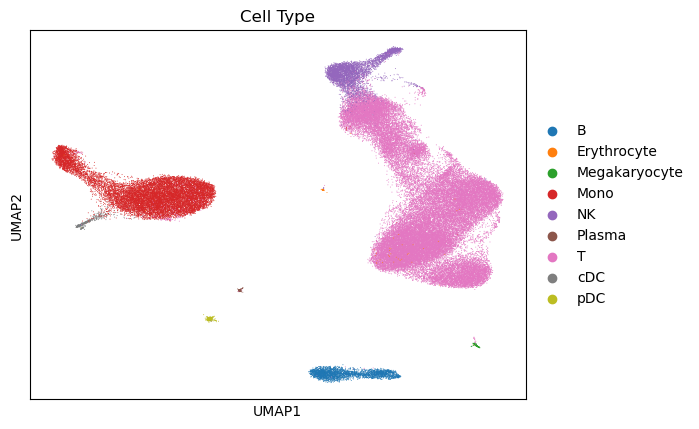

In [3]:
sc.pl.umap(adata, color='celltype', title='Cell Type')

In [4]:
# 5. 
query_adata = adata[adata.obs['celltype'] == 'Mono'].copy()
query_adata

AnnData object with n_obs × n_vars = 14721 × 21024
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'join_key', 'index', 'IDs', 'Names', 'SLEDAI', 'subclusters', 'clean_seq', 'sample', 'group', 'age_group', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype', 'barcode'
    uns: 'celltype_colors'
    obsm: 'X_harmony', 'X_pca', 'X_umap'

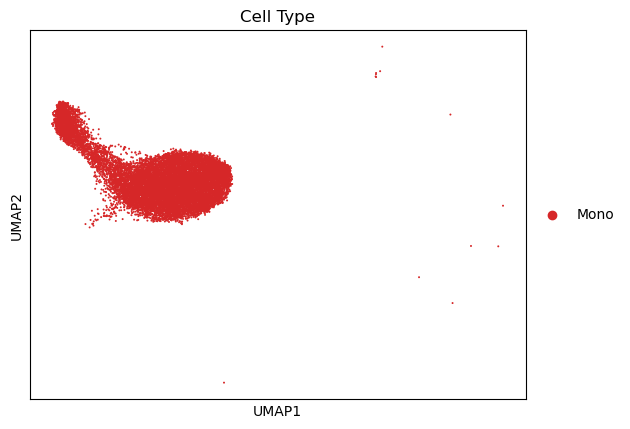

In [5]:
sc.pl.umap(query_adata, color='celltype', title='Cell Type')

In [6]:
# 1. 定义您想挑出的组名列表
target_groups = ['HD', 'SLE']  # 请根据第一步的输出结果修改这里！

# 2. 提取子集并生成一个新的 AnnData 对象
# 注意结尾加上 .copy()，避免修改子集时影响原数据
control_adata = query_adata[query_adata.obs['group'].isin(target_groups)].copy()

# 3. 查看提取后的结果
print(f"提取完成！剩余细胞数: {control_adata.n_obs}")
print("包含的组别:", control_adata.obs['group'].unique().tolist())
# 假设您的病人/样本 ID 存在 'sample' 列中 
# （如果实际存在 'ID' 或 'orig.ident' 列，请将下方的 'sample' 替换掉）

# ==========================================
# 1. 查看对照组中【总共】有几个不同的病人
# ==========================================
num_control_patients = control_adata.obs['sample'].nunique()
print(f"✅ 对照组中总共有 {num_control_patients} 个不重复的病人/样本。")

# ==========================================
# 2. 查看具体的【病人 ID 列表】
# ==========================================
control_patient_ids = control_adata.obs['sample'].unique().tolist()
print(f"🔍 对照组的病人 ID 列表: {control_patient_ids}")

# ==========================================
# 3. 进阶：查看【每个具体分组】下分别有几个病人
# ==========================================
# 比如看看 'Healthy' 里有几个，'Control' 里有几个
patients_per_group = control_adata.obs.groupby('group')['sample'].nunique()
print("\n📊 各个对照分组的病人数量统计：")
print(patients_per_group)

提取完成！剩余细胞数: 14721
包含的组别: ['HD', 'SLE']
✅ 对照组中总共有 12 个不重复的病人/样本。
🔍 对照组的病人 ID 列表: ['aHD1', 'aHD3', 'aSLE1', 'aSLE2', 'aSLE3', 'aSLE4', 'aHD4', 'aHD5', 'aHD6', 'aSLE5', 'aSLE6', 'aSLE7']

📊 各个对照分组的病人数量统计：
group
HD     5
SLE    7
Name: sample, dtype: int64


In [7]:

custom_tcat = starCAT(reference='/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.4.cNMF_Mono_Macro/Example_refbuilder_Macro/starcat_refstarcat_consensus_spectra_normalized.filtered.txt')

usage, _ = custom_tcat.fit_transform(query_adata)
usage

Using user specified reference spectra file /sibcb1/bioinformatics/yangyue/project/immunotherapy/7.4.cNMF_Mono_Macro/Example_refbuilder_Macro/starcat_refstarcat_consensus_spectra_normalized.filtered.txt
No scores provided
4579 out of 4579 genes in the reference overlap with the query


,cGEP1,cGEP2,cGEP3,cGEP4,cGEP5,cGEP6,cGEP7,cGEP8,cGEP9,cGEP10,...,cGEP68,cGEP69,cGEP70,cGEP71,cGEP72,cGEP73,cGEP74,cGEP75,cGEP76,cGEP77
GSM4029940_JB19001_AAACGGGTCACCGGGT-1,0.107894,0.007676,1.860327e-03,0.017003,0.086210,0.063444,0.000527,0.001806,0.002017,0.003910,...,0.010061,0.000283,0.015878,0.000879,0.001806,0.018773,0.002280,0.007973,0.003383,0.000082
GSM4029940_JB19001_AAATGCCCATTCTTAC-1,0.010398,0.033318,6.428615e-03,0.001467,0.010026,0.020613,0.357568,0.003916,0.003154,0.004666,...,0.020590,0.015142,0.014181,0.001768,0.000149,0.000666,0.002369,0.004394,0.014429,0.005165
GSM4029940_JB19001_AACCATGAGCCACGCT-1,0.015046,0.022332,1.057752e-02,0.012438,0.031068,0.040089,0.027483,0.015094,0.000935,0.006465,...,0.004095,0.019294,0.004145,0.009252,0.001408,0.003944,0.001000,0.000443,0.008829,0.039238
GSM4029940_JB19001_AACCATGAGTAGCGGT-1,0.223865,0.002600,5.469291e-03,0.000773,0.143116,0.061220,0.001199,0.007986,0.000409,0.005484,...,0.026430,0.004930,0.000769,0.004643,0.000753,0.081714,0.000617,0.000573,0.005066,0.003782
GSM4029940_JB19001_AACCATGGTGCATCTA-1,0.000351,0.000292,1.719972e-03,0.000780,0.002119,0.014125,0.518943,0.002356,0.001852,0.001156,...,0.000327,0.001986,0.001510,0.003687,0.009040,0.000068,0.015349,0.001465,0.007283,0.002952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM4029952_JB19015_TTTGGTTGTTCAGCGC-1,0.101857,0.013025,3.001583e-05,0.000412,0.216048,0.128451,0.000091,0.000651,0.000320,0.002468,...,0.002339,0.008220,0.000143,0.004713,0.000657,0.074509,0.000514,0.001032,0.000138,0.000615
GSM4029952_JB19015_TTTGGTTTCATTATCC-1,0.044665,0.017827,5.683150e-07,0.002377,0.023276,0.007510,0.000228,0.000005,0.000645,0.000002,...,0.000187,0.000225,0.000020,0.000072,0.000152,0.004650,0.000386,0.002601,0.000999,0.000160
GSM4029952_JB19015_TTTGTCACACCACCAG-1,0.015191,0.019976,3.136184e-03,0.002750,0.058814,0.037300,0.006006,0.000792,0.019837,0.004998,...,0.000027,0.021198,0.000697,0.001195,0.001701,0.014065,0.015020,0.000310,0.004644,0.000870
GSM4029952_JB19015_TTTGTCAGTGATAAGT-1,0.058902,0.000272,1.405322e-02,0.001423,0.066058,0.049574,0.003871,0.014046,0.009030,0.012003,...,0.002510,0.004598,0.003287,0.004604,0.000937,0.001869,0.007093,0.003133,0.001313,0.001189


In [8]:
# 加上个cGEP对应的注释
gep_anno = pd.read_csv("../3.1.Macro_GEP_Anno/3.3.Macro_cGEP_Anno_Complete_With_Genes.csv")
# 去掉 Class 为 Artifact 或 Doublet Lineage 的行
gep_anno_filt = gep_anno[~gep_anno["Category"].isin(["Artifact", "Doublet"])]
gep_anno_filt

,cGEP_Cluster,cGEP_Anno_Name,Category,cGEP_signature
0,cGEP1,Macro_M1_Invasive,Functional,"IL1B,PLAUR,SRGN,SOD2,EREG,NAMPT,BCL2A1,CXCL8,C..."
4,cGEP5,Mono_CD14_FCN1,Lineage,"S100A9,S100A8,LYZ,S100A12,VCAN,GAPDH,S100A6,FC..."
5,cGEP6,Mono_Classical_Trafficking,Lineage,"MTCO1P53,S100A9,S100A8,LYZ,FCN1,VCAN,S100A12,S..."
6,cGEP7,Mono_CD16,Lineage,"FCGR3A,LST1,IFITM2,RHOC,CNTN5,CDKN1C,SMIM25,IF..."
7,cGEP8,pDC,Lineage,"GZMB,CLEC4C,LILRA4,CLIC3,SMPD3,PACSIN1,LRRC26,..."
8,cGEP9,Macro_M2_Foam,Lineage,"ACP5,LGALS3,CALR,CD63,PLA2G7,FTL,CTSB,CTSD,TGF..."
9,cGEP10,mregDC,Lineage,"CCR7,FSCN1,LAMP3,BIRC3,LAD1,TXN,EBI3,CCL19,MAR..."
11,cGEP12,DC_cDC2_MHCII,Lineage,"HLA-DPB1,HLA-DPA1,HLA-DRA,HLA-DQB1,HLA-DQA1,CD..."
12,cGEP13,Macro_Osteoclast-like,Lineage,"CTSK,MMP9,CKB,SIGLEC15,SLC9B2,ACP5,AK5,NDRG4,C..."
15,cGEP16,Macro_M2_LAM,Lineage,"APOE,CTSD,GPNMB,APOC1,LGMN,CTSB,PSAP,C1QB,PLD3..."


In [9]:
# 1. 找出 Artifact / Doublet  对应的 cGEP 名称
remove_geps = (
    gep_anno.loc[
        gep_anno["Category"].isin(["Artifact", "Doublet"]),
        "cGEP_Cluster"]
    .unique()
    .tolist()
)

print("需要去掉的 cGEP：", remove_geps)

# 2. 从 usage 表格中去掉这些 cGEP 列
usage = usage.drop(columns=remove_geps, errors="ignore")

usage

需要去掉的 cGEP： ['cGEP2', 'cGEP3', 'cGEP4', 'cGEP11', 'cGEP14', 'cGEP15', 'cGEP17', 'cGEP24', 'cGEP28', 'cGEP31', 'cGEP33', 'cGEP35', 'cGEP40', 'cGEP42', 'cGEP44', 'cGEP45', 'cGEP46', 'cGEP50', 'cGEP55', 'cGEP56', 'cGEP57', 'cGEP58', 'cGEP60', 'cGEP61', 'cGEP62', 'cGEP63', 'cGEP64', 'cGEP65', 'cGEP68', 'cGEP69', 'cGEP71', 'cGEP72', 'cGEP73', 'cGEP74', 'cGEP75', 'cGEP76']


,cGEP1,cGEP5,cGEP6,cGEP7,cGEP8,cGEP9,cGEP10,cGEP12,cGEP13,cGEP16,...,cGEP49,cGEP51,cGEP52,cGEP53,cGEP54,cGEP59,cGEP66,cGEP67,cGEP70,cGEP77
GSM4029940_JB19001_AAACGGGTCACCGGGT-1,0.107894,0.086210,0.063444,0.000527,0.001806,0.002017,0.003910,0.007465,0.003706,0.004478,...,0.008932,0.029448,0.000242,0.014373,0.000435,0.003752,0.003503,0.000324,0.015878,0.000082
GSM4029940_JB19001_AAATGCCCATTCTTAC-1,0.010398,0.010026,0.020613,0.357568,0.003916,0.003154,0.004666,0.008111,0.000862,0.002152,...,0.021319,0.002738,0.005096,0.006099,0.010914,0.006211,0.002931,0.000034,0.014181,0.005165
GSM4029940_JB19001_AACCATGAGCCACGCT-1,0.015046,0.031068,0.040089,0.027483,0.015094,0.000935,0.006465,0.034618,0.006095,0.000867,...,0.053438,0.001734,0.002509,0.023732,0.001578,0.022458,0.000170,0.000094,0.004145,0.039238
GSM4029940_JB19001_AACCATGAGTAGCGGT-1,0.223865,0.143116,0.061220,0.001199,0.007986,0.000409,0.005484,0.005901,0.000355,0.000161,...,0.028982,0.001071,0.000229,0.023611,0.000059,0.003586,0.000614,0.000065,0.000769,0.003782
GSM4029940_JB19001_AACCATGGTGCATCTA-1,0.000351,0.002119,0.014125,0.518943,0.002356,0.001852,0.001156,0.003610,0.004056,0.002624,...,0.000366,0.000190,0.002435,0.003376,0.027984,0.000950,0.006831,0.000467,0.001510,0.002952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM4029952_JB19015_TTTGGTTGTTCAGCGC-1,0.101857,0.216048,0.128451,0.000091,0.000651,0.000320,0.002468,0.000192,0.000319,0.006213,...,0.003866,0.000882,0.017709,0.000084,0.002896,0.008380,0.009950,0.014219,0.000143,0.000615
GSM4029952_JB19015_TTTGGTTTCATTATCC-1,0.044665,0.023276,0.007510,0.000228,0.000005,0.000645,0.000002,0.000018,0.000003,0.002493,...,0.018632,0.279555,0.001440,0.000575,0.000780,0.000192,0.000657,0.073169,0.000020,0.000160
GSM4029952_JB19015_TTTGTCACACCACCAG-1,0.015191,0.058814,0.037300,0.006006,0.000792,0.019837,0.004998,0.008289,0.002959,0.057394,...,0.047834,0.011755,0.003365,0.032503,0.001457,0.003617,0.000494,0.000508,0.000697,0.000870
GSM4029952_JB19015_TTTGTCAGTGATAAGT-1,0.058902,0.066058,0.049574,0.003871,0.014046,0.009030,0.012003,0.133012,0.007066,0.004064,...,0.011383,0.000386,0.001651,0.010073,0.000936,0.003402,0.000935,0.058792,0.003287,0.001189


In [10]:
usage.to_csv("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.4.cNMF_Mono_Macro/5.disease/5.2.Macro.SLE_GSE145926_cGEP_usage_cell_level.csv")

In [11]:
# 1. 修正字典构建逻辑
# 去掉代码中的 "cGEP" 前缀，直接读取
anno_dict = {
    row['cGEP_Cluster']: f"{row['cGEP_Cluster']}_{row['cGEP_Anno_Name']}" 
    for index, row in gep_anno_filt.iterrows()
}

# 2. 再次检查映射字典
# 正确的样子应该是: [('cGEP1', 'cGEP1_Translation'), ...]
print("修正后的映射字典 (前3个):")
print(list(anno_dict.items())[:3])

# 3. 执行重命名
usage.rename(columns=anno_dict, inplace=True)

# 4. 验证结果
print("新的列名:")
print(usage.columns[:5])

修正后的映射字典 (前3个):
[('cGEP1', 'cGEP1_Macro_M1_Invasive'), ('cGEP5', 'cGEP5_Mono_CD14_FCN1'), ('cGEP6', 'cGEP6_Mono_Classical_Trafficking')]
新的列名:
Index(['cGEP1_Macro_M1_Invasive', 'cGEP5_Mono_CD14_FCN1',
       'cGEP6_Mono_Classical_Trafficking', 'cGEP7_Mono_CD16', 'cGEP8_pDC'],
      dtype='object')


In [12]:
# ===========================
# 步骤 1: 准备数据到 obs 中
# ===========================
print("正在将 Usage 数据同步到 adata.obs...")

# 获取 usage 表格中所有的列名（即所有的 GEP 名字）
all_gep_names = usage.columns.tolist()

# 将这些数据赋值给 query_adata.obs
# 我们加一个统一的前缀 "Usage: "，这样在图的标题里看起来更清晰
plot_features_list = []
for col in all_gep_names:
    # 新名字例如："Usage: cGEP1_Translation"
    new_obs_name = f"Usage: {col}"
    query_adata.obs[new_obs_name] = usage[col].values
    plot_features_list.append(new_obs_name)

n_geps = len(plot_features_list)
print(f"准备就绪，共计 {n_geps} 个 GEP 将被绘制。")

正在将 Usage 数据同步到 adata.obs...
准备就绪，共计 41 个 GEP 将被绘制。


正在将 Usage 数据同步到 adata.obs...
准备就绪，共计 41 个 GEP 将被绘制。
开始绘制 UMAP，这可能需要一点时间...


/var/tmp/ipykernel_18357/3895156732.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()



>>> 绘图完成！ <<<


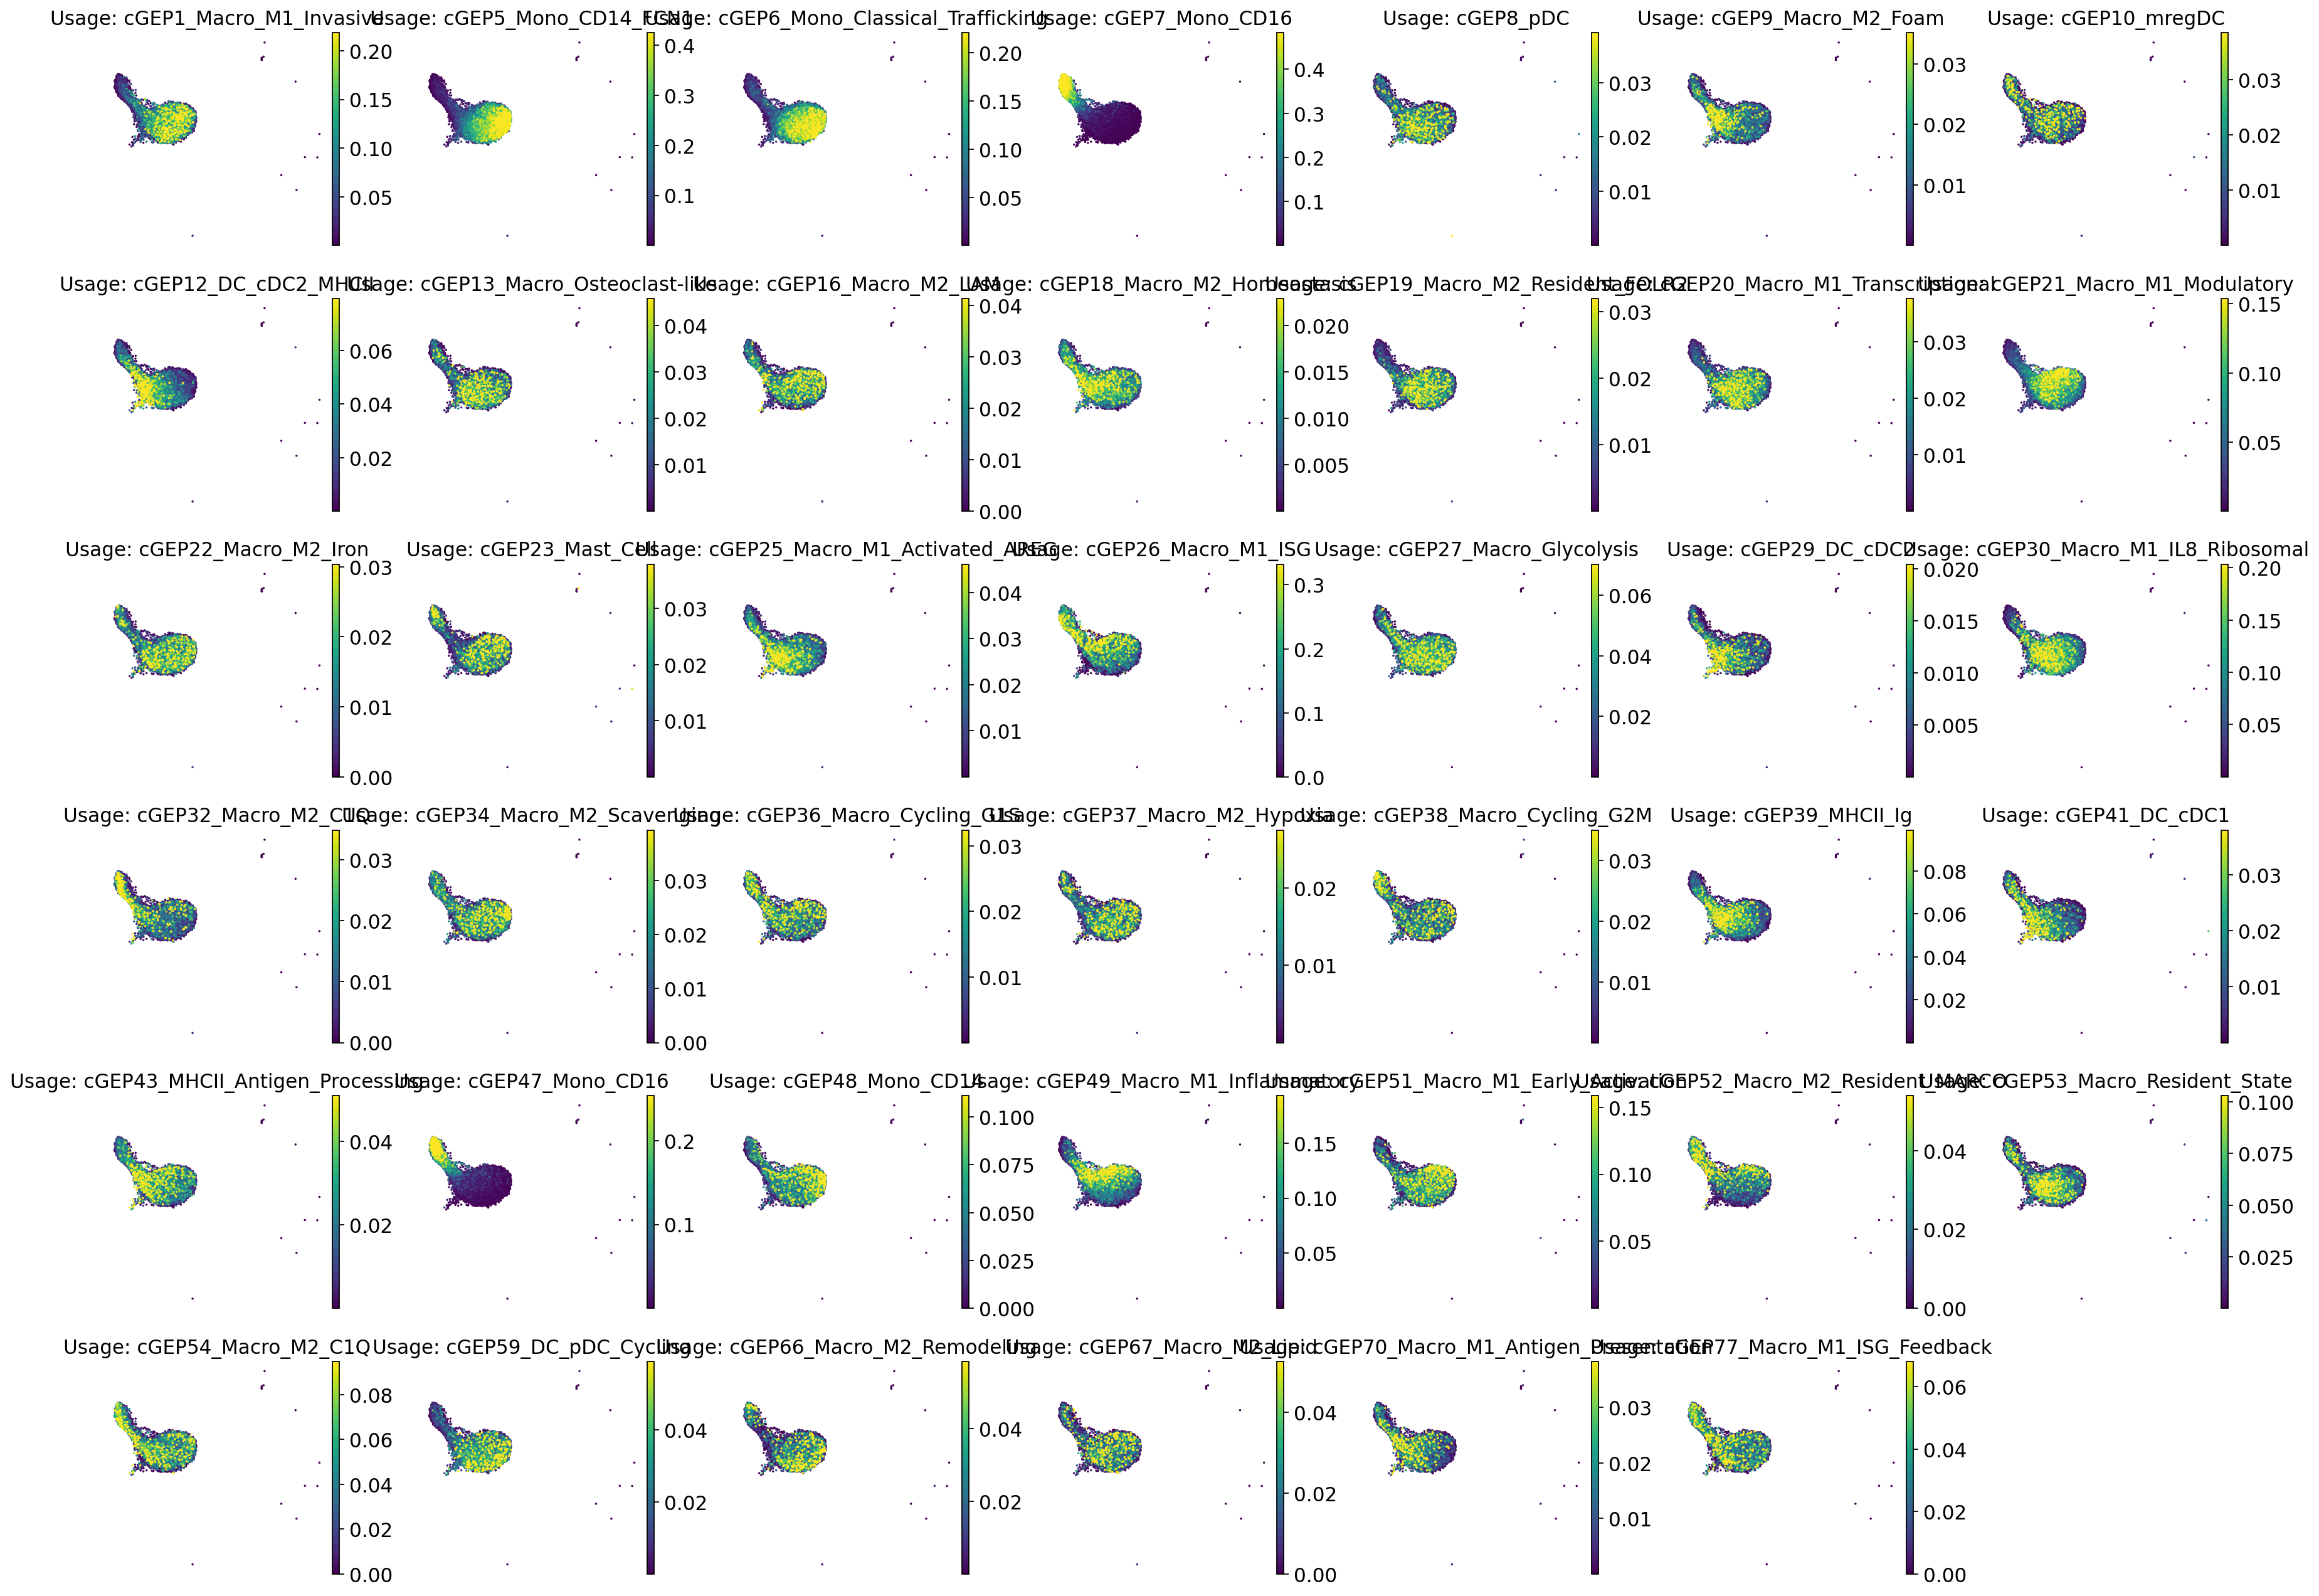

In [13]:
# ===========================
# 步骤 1: 准备数据到 obs 中
# ===========================
print("正在将 Usage 数据同步到 adata.obs...")

# 获取 usage 表格中所有的列名（即所有的 GEP 名字）
all_gep_names = usage.columns.tolist()

# 将这些数据赋值给 query_adata.obs
# 我们加一个统一的前缀 "Usage: "，这样在图的标题里看起来更清晰
plot_features_list = []
for col in all_gep_names:
    # 新名字例如："Usage: cGEP1_Translation"
    new_obs_name = f"Usage: {col}"
    query_adata.obs[new_obs_name] = usage[col].values
    plot_features_list.append(new_obs_name)

n_geps = len(plot_features_list)
print(f"准备就绪，共计 {n_geps} 个 GEP 将被绘制。")


# ===========================
# 步骤 2: 批量绘图并保存
# ===========================
print("开始绘制 UMAP，这可能需要一点时间...")

# 设置绘图参数
sc.set_figure_params(dpi_save=300, figsize=(3, 3)) # 设置每一张小图的尺寸和保存分辨率

plot = sc.pl.umap(
    query_adata,
    color=plot_features_list, # 传入包含所有名字的列表
    vmax='p99',        # 关键：切除前1%的极端值，否则图可能一片黑
    cmap='viridis',    # 配色方案：viridis(黄紫), plasma(黄蓝), Reds(红)
    ncols=7,           # 每行显示 7 张图 (根据总数调整，70个正好画10行)
    s=10,              # 点的大小
    frameon=False,     # 去掉外边框，更美观
    show=False,        # 关键：设置为 False，不直接在屏幕显示
    return_fig=True    # 返回图像对象以便保存
)
plot.show()
# 定义保存路径
#output_filename = "5.All_GEP_Usage_Visualization.png"

# 保存图片
# bbox_inches='tight' 可以去除多余白边
#plot.savefig(output_filename, bbox_inches='tight')

print(f"\n>>> 绘图完成！ <<<")


图片已保存为: ./5.2.SLE/5.Mono_Macro_SLE_Usage_group_Heatmap.png


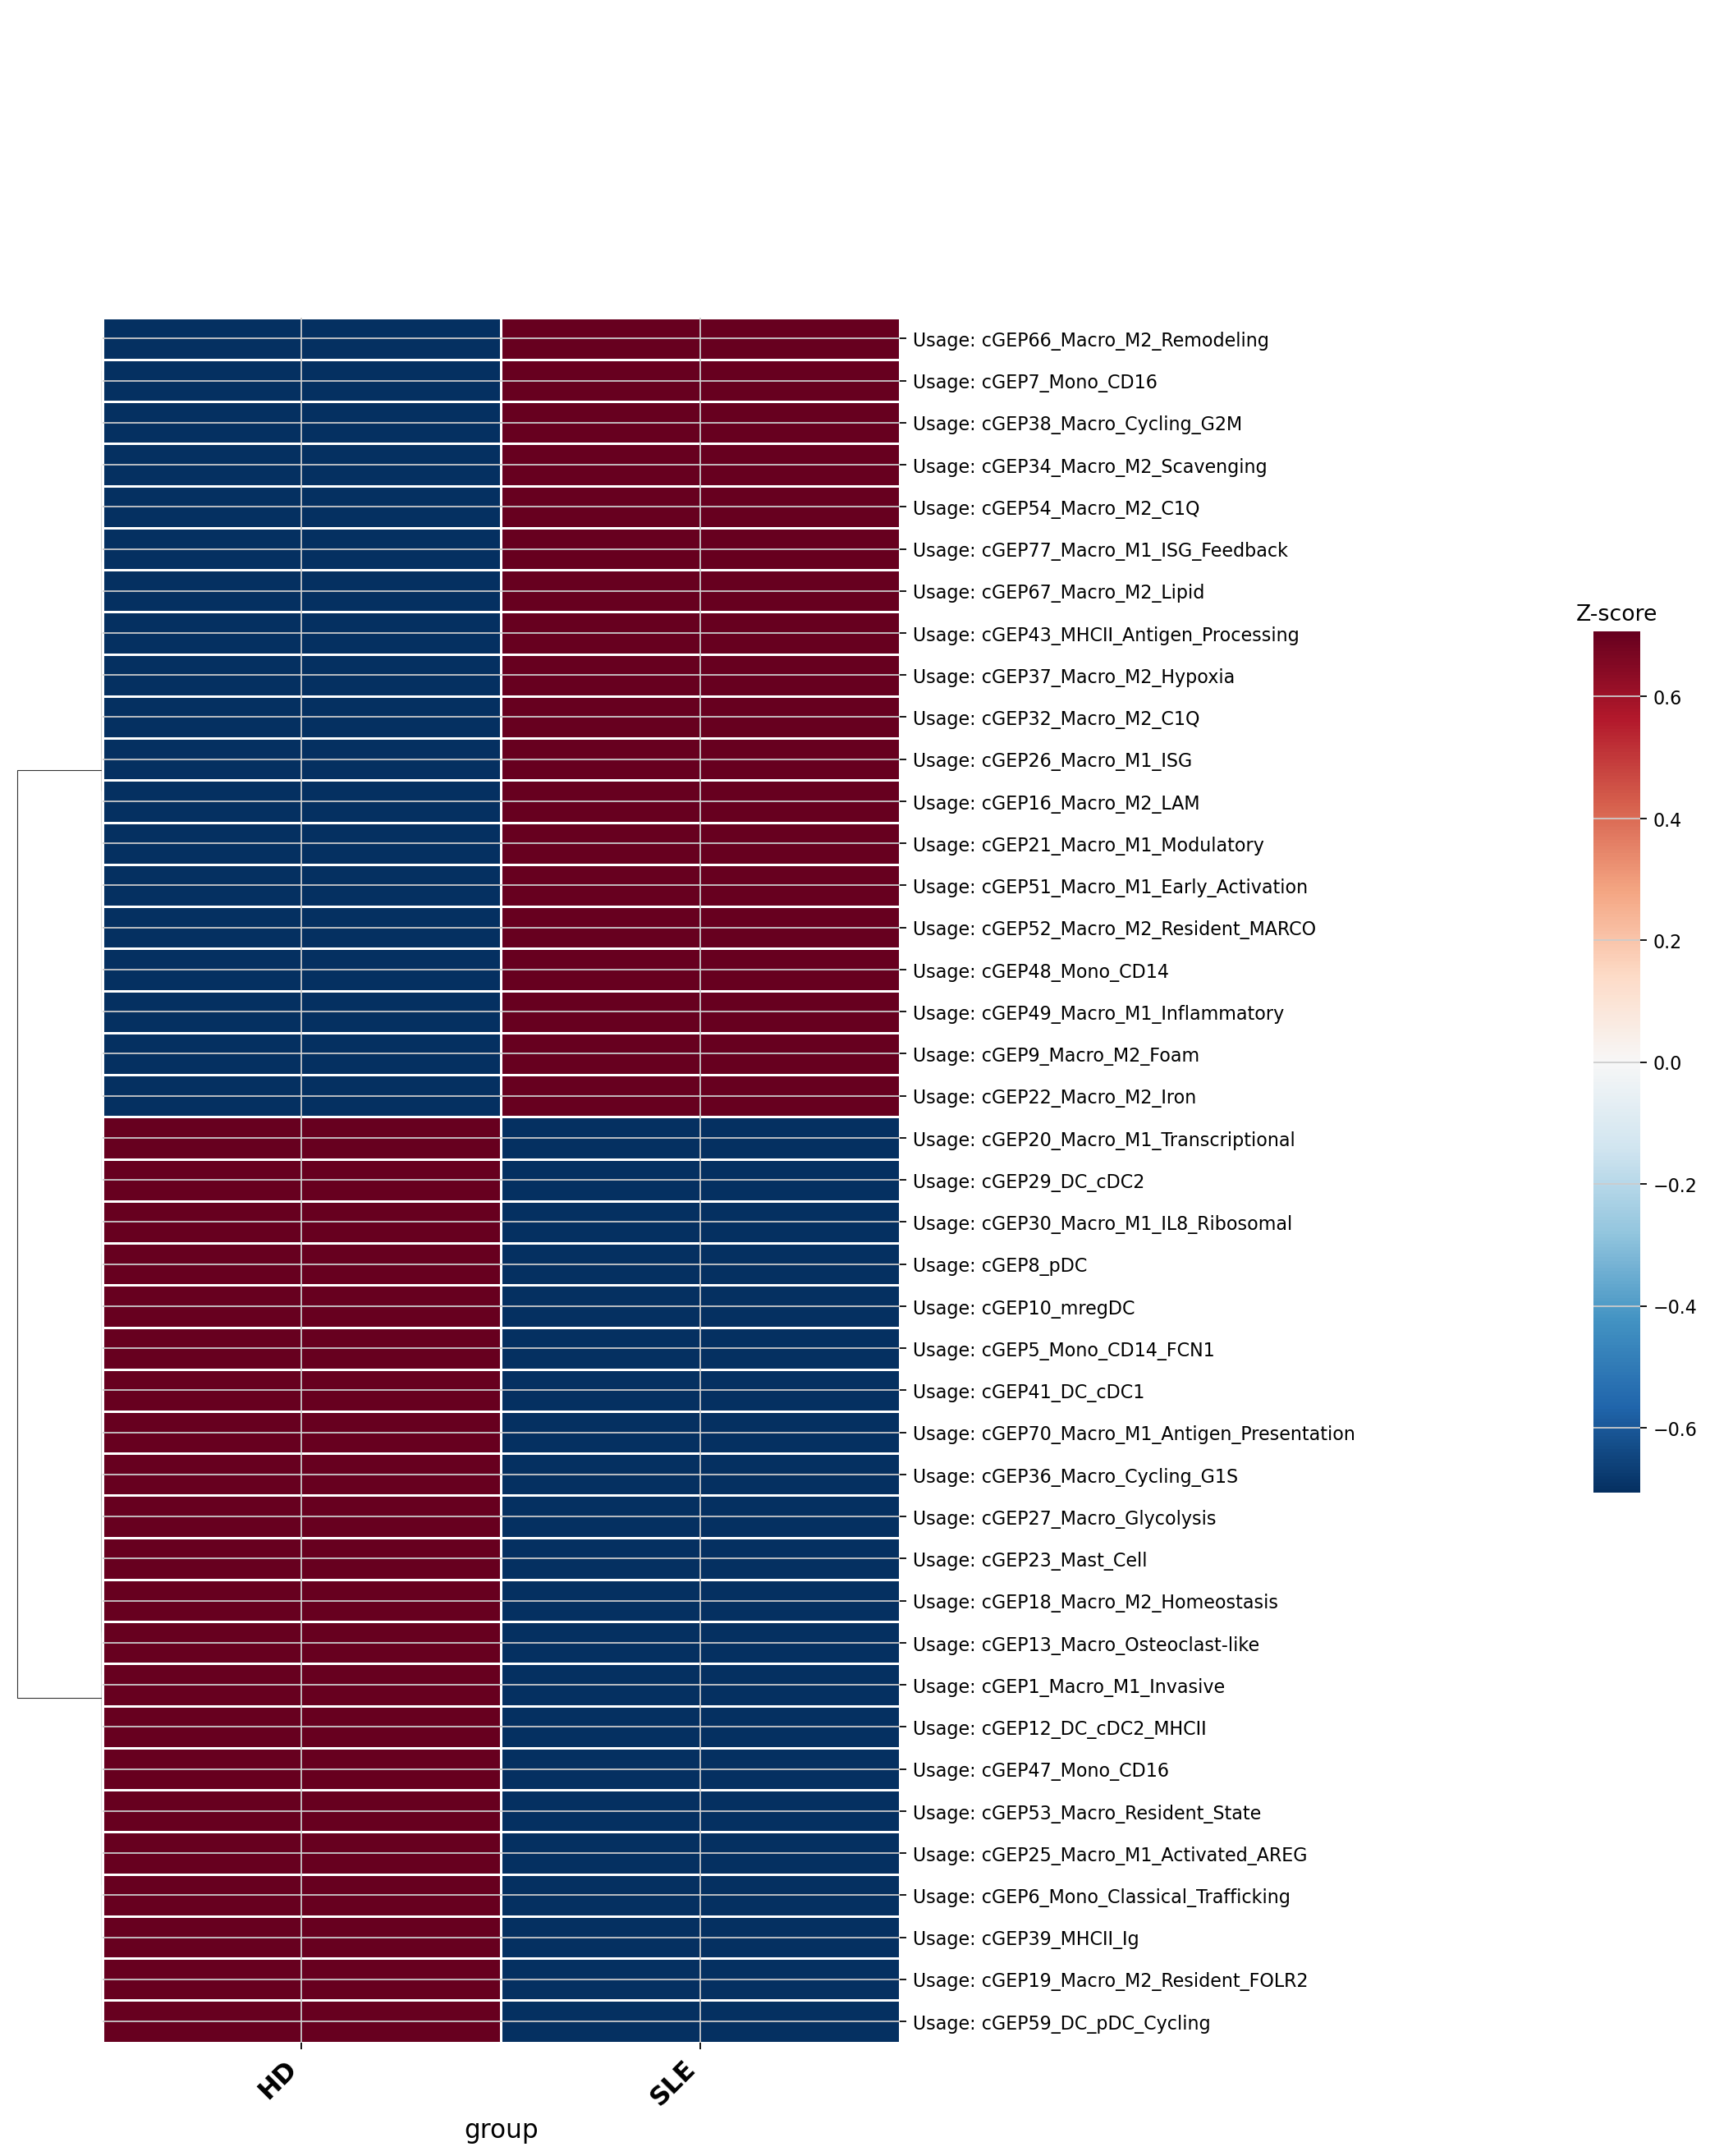

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 筛选数据 (保持不变)
usage_features = [col for col in query_adata.obs.columns if col.startswith('Usage:')]
df = query_adata.obs[usage_features + ['group']]
mean_usage = df.groupby('group').mean()

# 2. 绘制热图
g = sns.clustermap(
    mean_usage.T,
    z_score=0,
    cmap='RdBu_r',
    center=0,
    col_cluster=False,
    # 画布大小
    figsize=(12, len(usage_features) * 0.4),
    cbar_pos=(1.02, 0.3, 0.03, 0.4), 
    dendrogram_ratio=(0.1, 0.15),
    linewidths=0.5,
    linecolor='white',
    xticklabels=True,
    yticklabels=True
)

# 3. 调整字体和样式
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=14, fontweight='bold', rotation=45, ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=10)

# 4. 优化右侧图例的标签
g.ax_cbar.set_title('Z-score', fontsize=12) # 给图例加标题
g.ax_cbar.tick_params(labelsize=10)         # 调整图例刻度字号

# 5. 保存 (bbox_inches='tight' 至关重要，否则右边的图例会被切掉)
output_filename = "./5.2.SLE/5.Mono_Macro_SLE_Usage_group_Heatmap.png"
g.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"图片已保存为: {output_filename}")

plt.show()

分组统计:
SLE        8827
Healthy    5894
Name: group2_condition, dtype: int64

数据预览:
                                      group group2_condition
GSM4029940_JB19001_AAACGGGTCACCGGGT-1    HD          Healthy
GSM4029940_JB19001_AAATGCCCATTCTTAC-1    HD          Healthy
GSM4029940_JB19001_AACCATGAGCCACGCT-1    HD          Healthy
GSM4029940_JB19001_AACCATGAGTAGCGGT-1    HD          Healthy
GSM4029940_JB19001_AACCATGGTGCATCTA-1    HD          Healthy
分析完成。前 5 个显著差异 GEP:
                                  GEP_Name    log2FC           padj
0               Usage: cGEP26_Macro_M1_ISG  3.877307   0.000000e+00
1               Usage: cGEP54_Macro_M2_C1Q  1.853750  7.610468e-277
2      Usage: cGEP77_Macro_M1_ISG_Feedback  1.530914  3.613188e-254
3  Usage: cGEP51_Macro_M1_Early_Activation  1.513406  1.290203e-225
4    Usage: cGEP52_Macro_M2_Resident_MARCO  1.143785  1.743650e-177
图片已保存为: ./5.2.SLE/5.2.Mono-Macro_SLE_Volcano_Usage_Publication.png


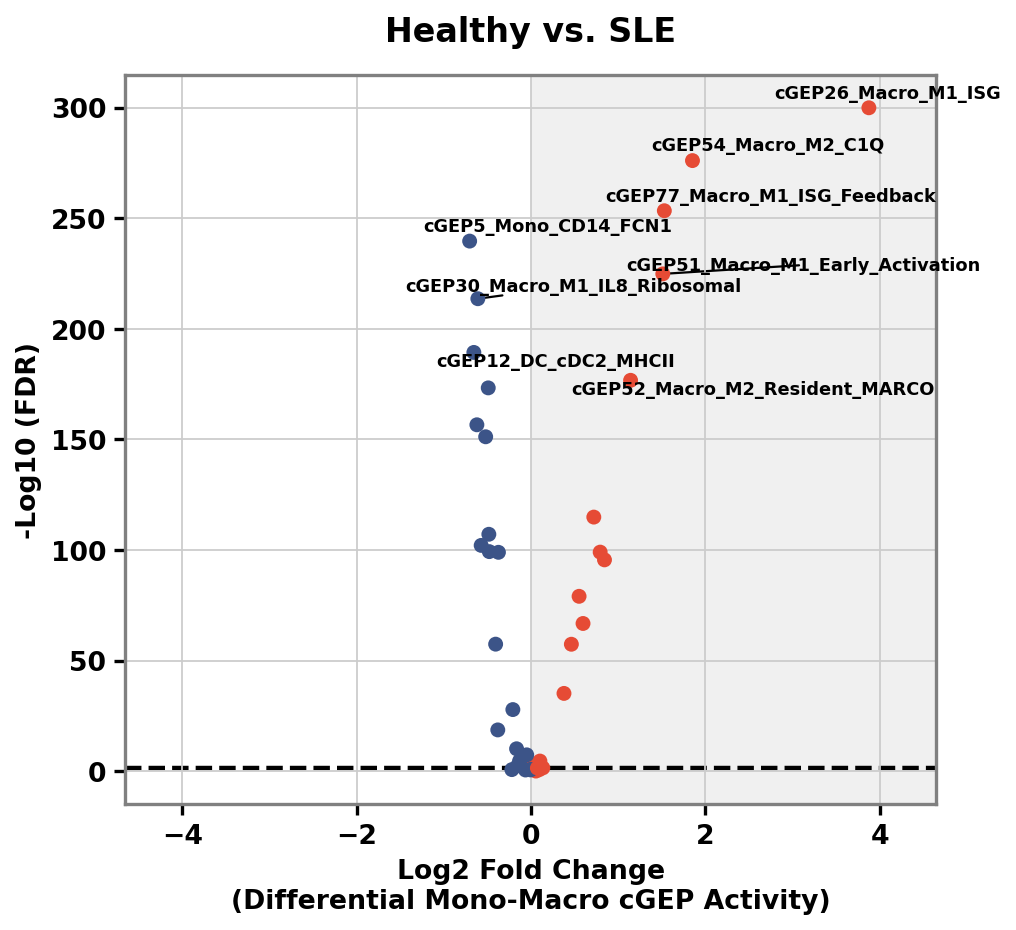

In [15]:
# 1. 定义映射关系
# 这里的逻辑是：HC -> Healthy, S和M -> COVID
mapping = {
    'HD': 'Healthy',
    'SLE':  'SLE'
}

# 2. 创建新列 'condition'
# 使用 map 函数自动转换
query_adata.obs['group2_condition'] = query_adata.obs['group'].map(mapping)

# 3. 检查一下结果
print("分组统计:")
print(query_adata.obs['group2_condition'].value_counts())

# 检查前几行，确保没填错
print("\n数据预览:")
print(query_adata.obs[['group', 'group2_condition']].head())

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# ===========================
# 第一步：准备数据与差异分析
# ===========================

# 1. 提取所有 Usage 列
usage_cols = [c for c in query_adata.obs.columns if c.startswith('Usage:')]
gep_data = query_adata.obs[usage_cols]

# 2. 创建临时 AnnData 对象
gep_adata = sc.AnnData(X=gep_data.values, obs=query_adata.obs)
gep_adata.var_names = usage_cols

# 3. 运行差异分析 (Wilcoxon 秩和检验)
sc.tl.rank_genes_groups(
    gep_adata, 
    groupby='group2_condition',  # 使用您刚才创建的分组
    groups=['SLE'],            # 实验组：
    reference='Healthy',         # 对照组：Healthy
    method='wilcoxon'
)
# 4. 提取结果表
result = sc.get.rank_genes_groups_df(gep_adata, group='SLE')
df_volcano = result[['names', 'logfoldchanges', 'pvals_adj']].copy()
df_volcano.columns = ['GEP_Name', 'log2FC', 'padj']

# 去除无效值
df_volcano = df_volcano.replace([np.inf, -np.inf], np.nan).dropna()
print("分析完成。前 5 个显著差异 GEP:")
print(df_volcano.head())

# ===========================
# 第二步：绘制高分文献风格火山图
# ===========================

# 1. 设置显著性阈值
pval_th = 0.05
# 参考图只画了横线，因此不再设置强硬的竖线 logFC 阈值，靠左右分布区分

# 2. 定义颜色 (仿照参考图，按正负着色：右侧红色，左侧蓝色)
df_volcano['color'] = np.where(df_volcano['log2FC'] > 0, '#E64B35', '#3C5488') 
df_volcano['alpha'] = 1.0

# 计算 -log10 P值
df_volcano['log_pval'] = -np.log10(df_volcano['padj'] + 1e-300) 

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(6.5, 6)) # 采用接近正方形的比例

# 【关键特征】添加右侧灰色阴影背景
# 获取X轴最大值以确定阴影右边界
x_max = abs(df_volcano['log2FC']).max() * 1.2 
ax.axvspan(0, x_max, facecolor='#f0f0f0', zorder=0)

# 绘制散点
ax.scatter(
    df_volcano['log2FC'], 
    df_volcano['log_pval'], 
    c=df_volcano['color'], 
    s=45, 
    alpha=df_volcano['alpha'], 
    edgecolors='none', 
    zorder=2
)

# 【关键特征】只添加水平黑色粗虚线作为 Q-value/P-value 阈值
ax.axhline(y=-np.log10(pval_th), color='black', linestyle='--', linewidth=2, zorder=1)

# 4. 标注显著的点
texts = []
# 选取 P 值最显著的 top 15 个点进行标注（由于没有中间的垂直线，符合条件的可能较多）
sig_genes = df_volcano[df_volcano['padj'] < pval_th].sort_values('padj')
top_genes = sig_genes.head(8)

for _, row in top_genes.iterrows():
    simple_name = row['GEP_Name'].replace('Usage: ', '')
    # 【全局加粗】添加字体加粗参数 fontweight='bold'
    texts.append(ax.text(row['log2FC'], row['log_pval'], simple_name, 
                         fontsize=8, fontweight='bold', zorder=3))

# 使用 adjust_text 自动避让
try:
    # 【关键特征】连线使用简单的黑色直线，不带箭头
    adjust_text(texts, 
                arrowprops=dict(arrowstyle='-', color='black', lw=1.0),
                ax=ax)
except NameError:
    print("提示: 未安装 adjustText，标签可能会重叠。")

# 5. 装饰图片与【全局加粗】
ax.set_title('Healthy vs. SLE', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel(f'Log2 Fold Change\n(Differential Mono-Macro cGEP Activity)', fontsize=12, fontweight='bold') 
ax.set_ylabel('-Log10 (FDR)', fontsize=12, fontweight='bold')

# 加粗刻度文字
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# 加粗坐标轴边框
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#808080')
ax.tick_params(width=1.5, length=5) # 加粗刻度线本身

# 设置对称的 X 轴范围，使 0 刻度居中，视觉效果更好
ax.set_xlim(-x_max, x_max)

# 保存与展示
import os

output_file = "./5.2.SLE/5.2.Mono-Macro_SLE_Volcano_Usage_Publication.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"图片已保存为: {output_file}")
plt.show()

分组统计:
SLE        8827
Healthy    5894
Name: group2_condition, dtype: int64

正在对比: SLE vs Healthy (HC)...

分析完成。以下是将在火山图上标注的极显著 cGEP：

--- 在 SLE 中最显著上调的 Top 5 cGEP (对应图右侧红点) ---
                           GEP_Name   log2FC          padj   log_pval
         Usage: cGEP26_Macro_M1_ISG 3.877307 1.000000e-300 300.000000
         Usage: cGEP54_Macro_M2_C1Q 1.853750 7.610468e-277 276.118589
Usage: cGEP77_Macro_M1_ISG_Feedback 1.530914 3.613188e-254 253.442109

--- 在 SLE 中最显著下调的 Top 5 cGEP (对应图左侧蓝点) ---
                            GEP_Name    log2FC          padj   log_pval
         Usage: cGEP5_Mono_CD14_FCN1 -0.702395 1.941166e-240 239.711937
Usage: cGEP30_Macro_M1_IL8_Ribosomal -0.608311 2.193444e-214 213.658874
         Usage: cGEP12_DC_cDC2_MHCII -0.654181 4.241094e-190 189.372522

图片已保存为: ./5.2.SLE/5.2.Mono-Macro_SLE_Volcano_Usage_Publication-v0420.pdf


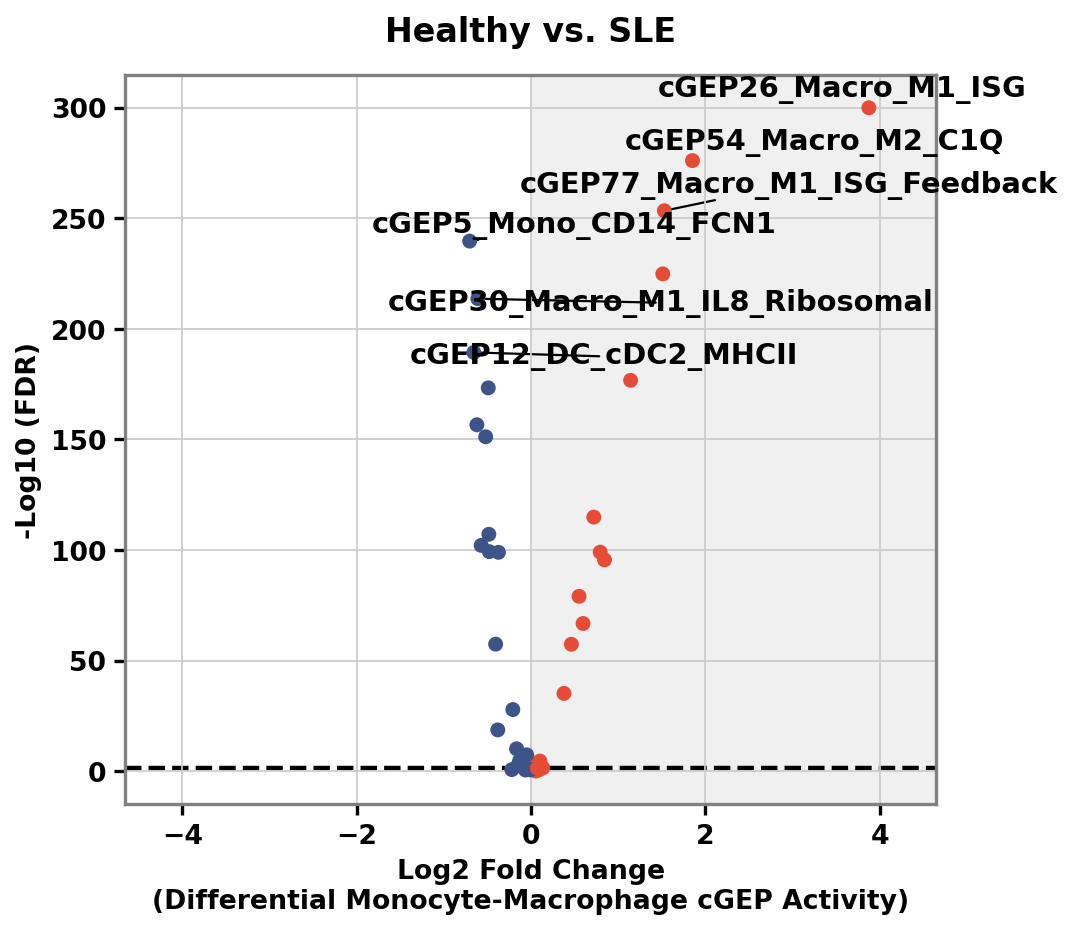

In [21]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from adjustText import adjust_text
except ImportError:
    pass

# ===========================
# 第一步：准备数据与差异分析
# ===========================

# 1. 定义映射关系并创建新列 (HC -> Healthy, SLE -> SLE)
mapping = {'HD': 'Healthy', 'SLE': 'SLE'}
# 使用 map 函数自动转换
query_adata.obs['group2_condition'] = query_adata.obs['group'].map(mapping)

print("分组统计:")
print(query_adata.obs['group2_condition'].value_counts())

# 2. 提取所有 Usage 列并创建临时 AnnData 对象
usage_cols = [c for c in query_adata.obs.columns if c.startswith('Usage:')]
gep_data = query_adata.obs[usage_cols]

gep_adata = sc.AnnData(X=gep_data.values, obs=query_adata.obs)
gep_adata.var_names = usage_cols

# 3. 运行差异分析 (Wilcoxon 秩和检验)
print("\n正在对比: SLE vs Healthy (HC)...")
sc.tl.rank_genes_groups(
    gep_adata, 
    groupby='group2_condition',  
    groups=['SLE'],            
    reference='Healthy',         
    method='wilcoxon'
)

# 4. 提取结果表
result = sc.get.rank_genes_groups_df(gep_adata, group='SLE')
df_volcano = result[['names', 'logfoldchanges', 'pvals_adj']].copy()
df_volcano.columns = ['GEP_Name', 'log2FC', 'padj']

# ===========================
# 第二步：数据清洗与提取最显著基因
# ===========================
pval_th = 0.05

# 去除无效值，并科学处理极小 P 值防止 -log10 报错
df_volcano = df_volcano.replace([np.inf, -np.inf], np.nan).dropna()
df_volcano['padj'] = df_volcano['padj'].clip(lower=1e-300) 
df_volcano['log_pval'] = -np.log10(df_volcano['padj'])

# 提取 P 值最显著的 Top 5 上调和下调 cGEP（用于打印和图表标注）
top_up = df_volcano[(df_volcano['log2FC'] > 0) & (df_volcano['padj'] < pval_th)].sort_values('padj').head(3)
top_dn = df_volcano[(df_volcano['log2FC'] < 0) & (df_volcano['padj'] < pval_th)].sort_values('padj').head(3)

# 合并，变量名为 top_genes
top_genes = pd.concat([top_up, top_dn])

print("\n分析完成。以下是将在火山图上标注的极显著 cGEP：")
print("\n--- 在 SLE 中最显著上调的 Top 5 cGEP (对应图右侧红点) ---")
print(top_up[['GEP_Name', 'log2FC', 'padj', 'log_pval']].to_string(index=False))

print("\n--- 在 SLE 中最显著下调的 Top 5 cGEP (对应图左侧蓝点) ---")
print(top_dn[['GEP_Name', 'log2FC', 'padj', 'log_pval']].to_string(index=False))

# ===========================
# 第三步：绘制高分文献风格火山图
# ===========================

# 1. 定义颜色 (按正负着色：右侧红色，左侧蓝色)
df_volcano['color'] = np.where(df_volcano['log2FC'] > 0, '#E64B35', '#3C5488') 
df_volcano['alpha'] = 1.0

# 2. 开始绘图
fig, ax = plt.subplots(figsize=(6.5, 6)) # 采用接近正方形的比例

# 添加右侧灰色阴影背景
x_max = abs(df_volcano['log2FC']).max() * 1.2 
ax.axvspan(0, x_max, facecolor='#f0f0f0', zorder=0)

# 绘制散点
ax.scatter(
    df_volcano['log2FC'], 
    df_volcano['log_pval'], 
    c=df_volcano['color'], 
    s=45, 
    alpha=df_volcano['alpha'], 
    edgecolors='none', 
    zorder=2
)

# 只有水平黑色粗虚线作为 P-value 阈值
ax.axhline(y=-np.log10(pval_th), color='black', linestyle='--', linewidth=2, zorder=1)

# 3. 标注显著的点 (使用刚刚提取的 top_genes)
texts = []
for _, row in top_genes.iterrows():
    simple_name = row['GEP_Name'].replace('Usage: ', '')
    # 全局加粗
    texts.append(ax.text(row['log2FC'], row['log_pval'], simple_name, 
                         fontsize=13, fontweight='bold', zorder=3))

# 使用 adjust_text 自动避让
try:
    # 连线使用简单的黑色直线，不带箭头
    adjust_text(texts, 
                arrowprops=dict(arrowstyle='-', color='black', lw=1.0),
                ax=ax)
except NameError:
    print("提示: 未安装 adjustText，标签可能会重叠。")

# 4. 装饰图片与全局加粗
ax.set_title('Healthy vs. SLE', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Log2 Fold Change\n(Differential Monocyte-Macrophage cGEP Activity)', fontsize=12, fontweight='bold') 
ax.set_ylabel('-Log10 (FDR)', fontsize=12, fontweight='bold')

# 加粗刻度文字
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# 加粗坐标轴边框
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#808080')
ax.tick_params(width=1.5, length=5) # 加粗刻度线本身

# 设置对称的 X 轴范围，使 0 刻度居中
ax.set_xlim(-x_max, x_max)

# ===========================
# 第四步：保存与展示
# ===========================
os.makedirs("./5.2.SLE", exist_ok=True)
output_file = "./5.2.SLE/5.2.Mono-Macro_SLE_Volcano_Usage_Publication-v0420.pdf"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n图片已保存为: {output_file}")
plt.show()